 SECTION 1 — DATA LOADING
  ✔ File loaded       : HousingData.csv
  ✔ Shape             : 506 rows × 14 columns
  ✔ Memory usage      : 55.5 KB

First 5 rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  

 SECTION 2 — DATA QUALITY ASSESSMENT

[2a] Column Data Types:
CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        flo

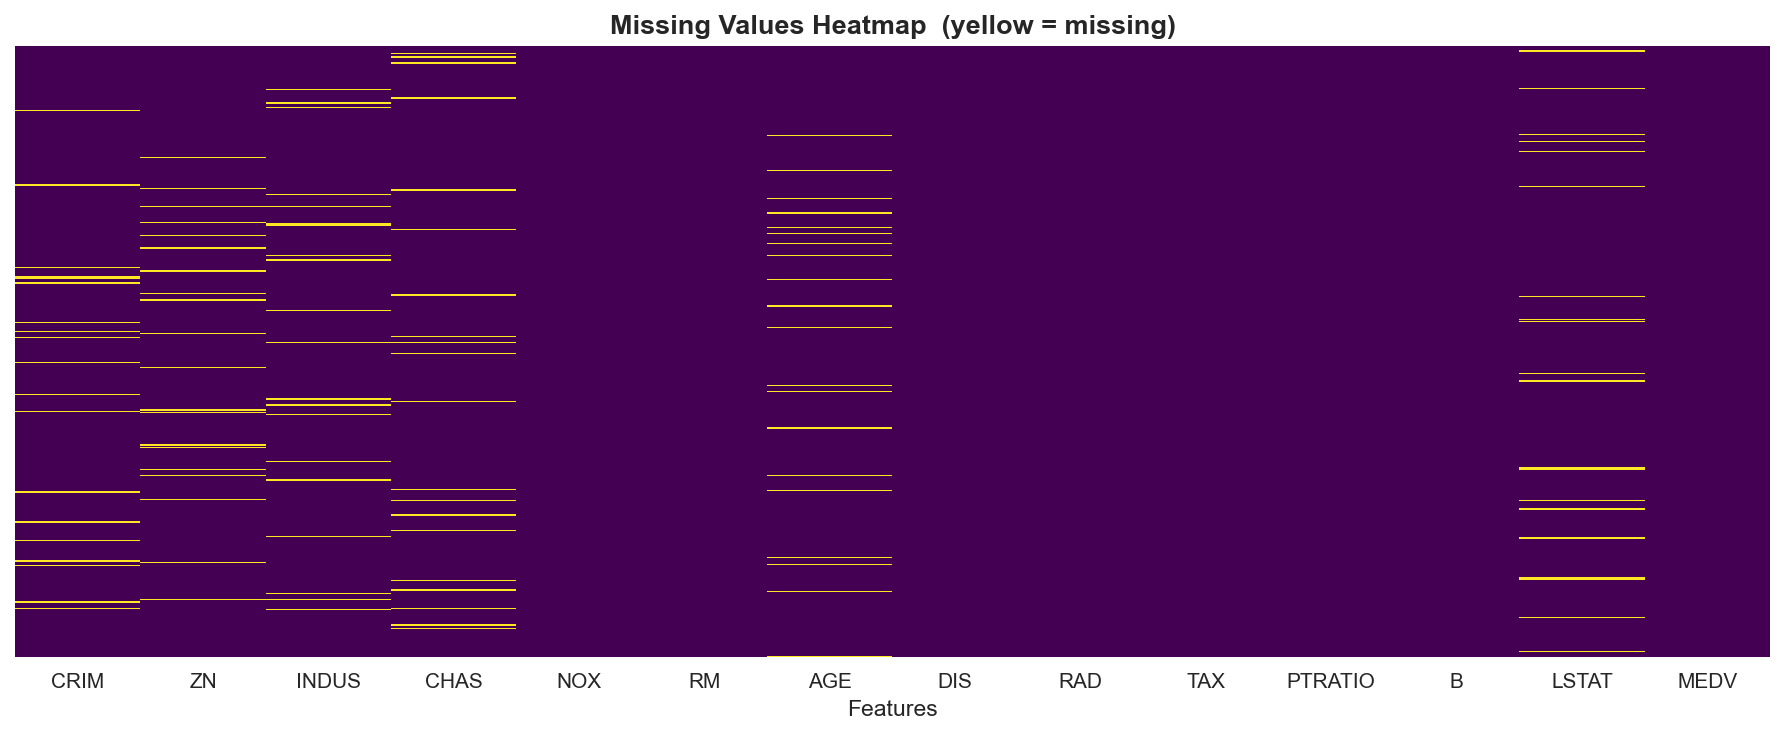

  → Saved: 01_missing_values_heatmap.png

 SECTION 3 — DATA CLEANING

[3a] Numerical imputation (median strategy):
  CRIM       → 20 value(s) filled with median = 0.254
  ZN         → 20 value(s) filled with median = 0.000
  INDUS      → 20 value(s) filled with median = 9.690
  CHAS       → 20 value(s) filled with median = 0.000
  AGE        → 20 value(s) filled with median = 76.800
  LSTAT      → 20 value(s) filled with median = 11.430

[3b] Categorical imputation (mode strategy):
  No categorical columns found — skipping.

[3c] Duplicate removal:
  Removed 0 duplicate row(s).

  ✔ Cleaned shape         : (506, 14)
  ✔ Remaining missing cells: 0

 SECTION 4 — OUTLIER DETECTION  (IQR Method)

              Q1       Q3      IQR  Lower Fence  Upper Fence  Outliers Outlier %
Feature                                                                         
CRIM       0.083    2.809    2.725       -4.005        6.897        81     16.0%
ZN         0.000    0.000    0.000        0.000        

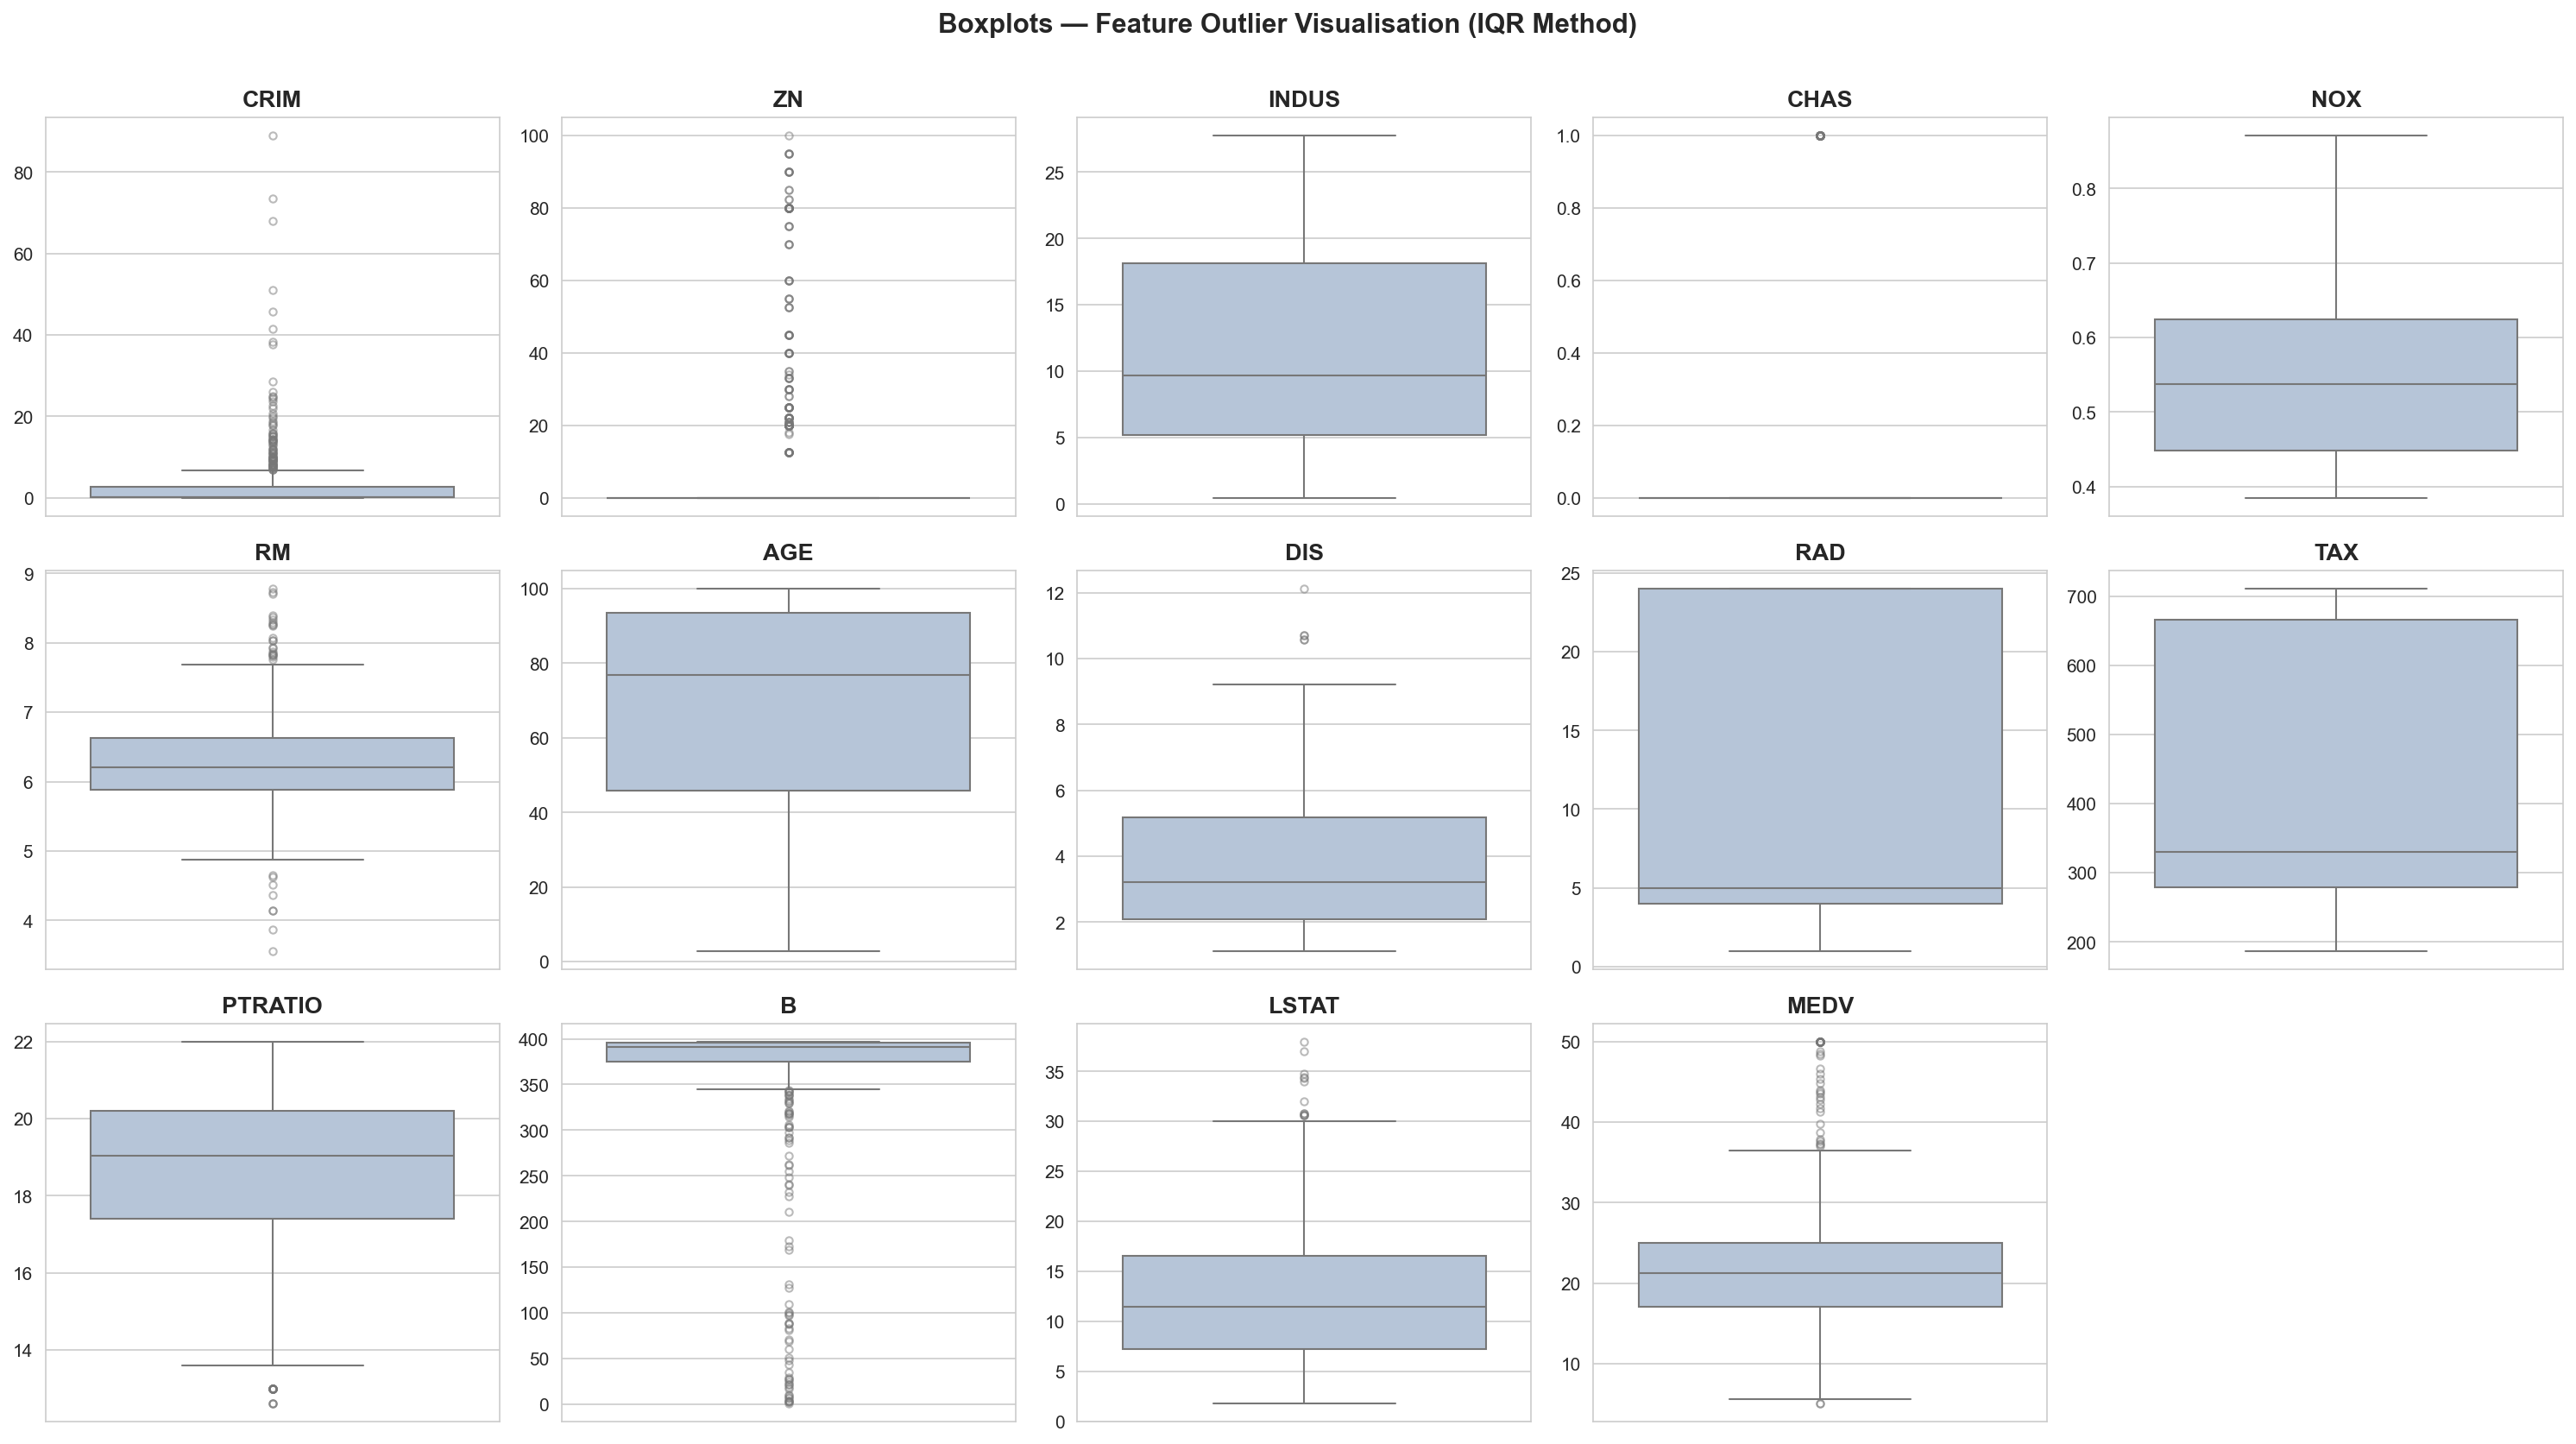

  → Saved: 02_boxplots_all_features.png

 SECTION 5 — UNIVARIATE ANALYSIS  (Distributions)


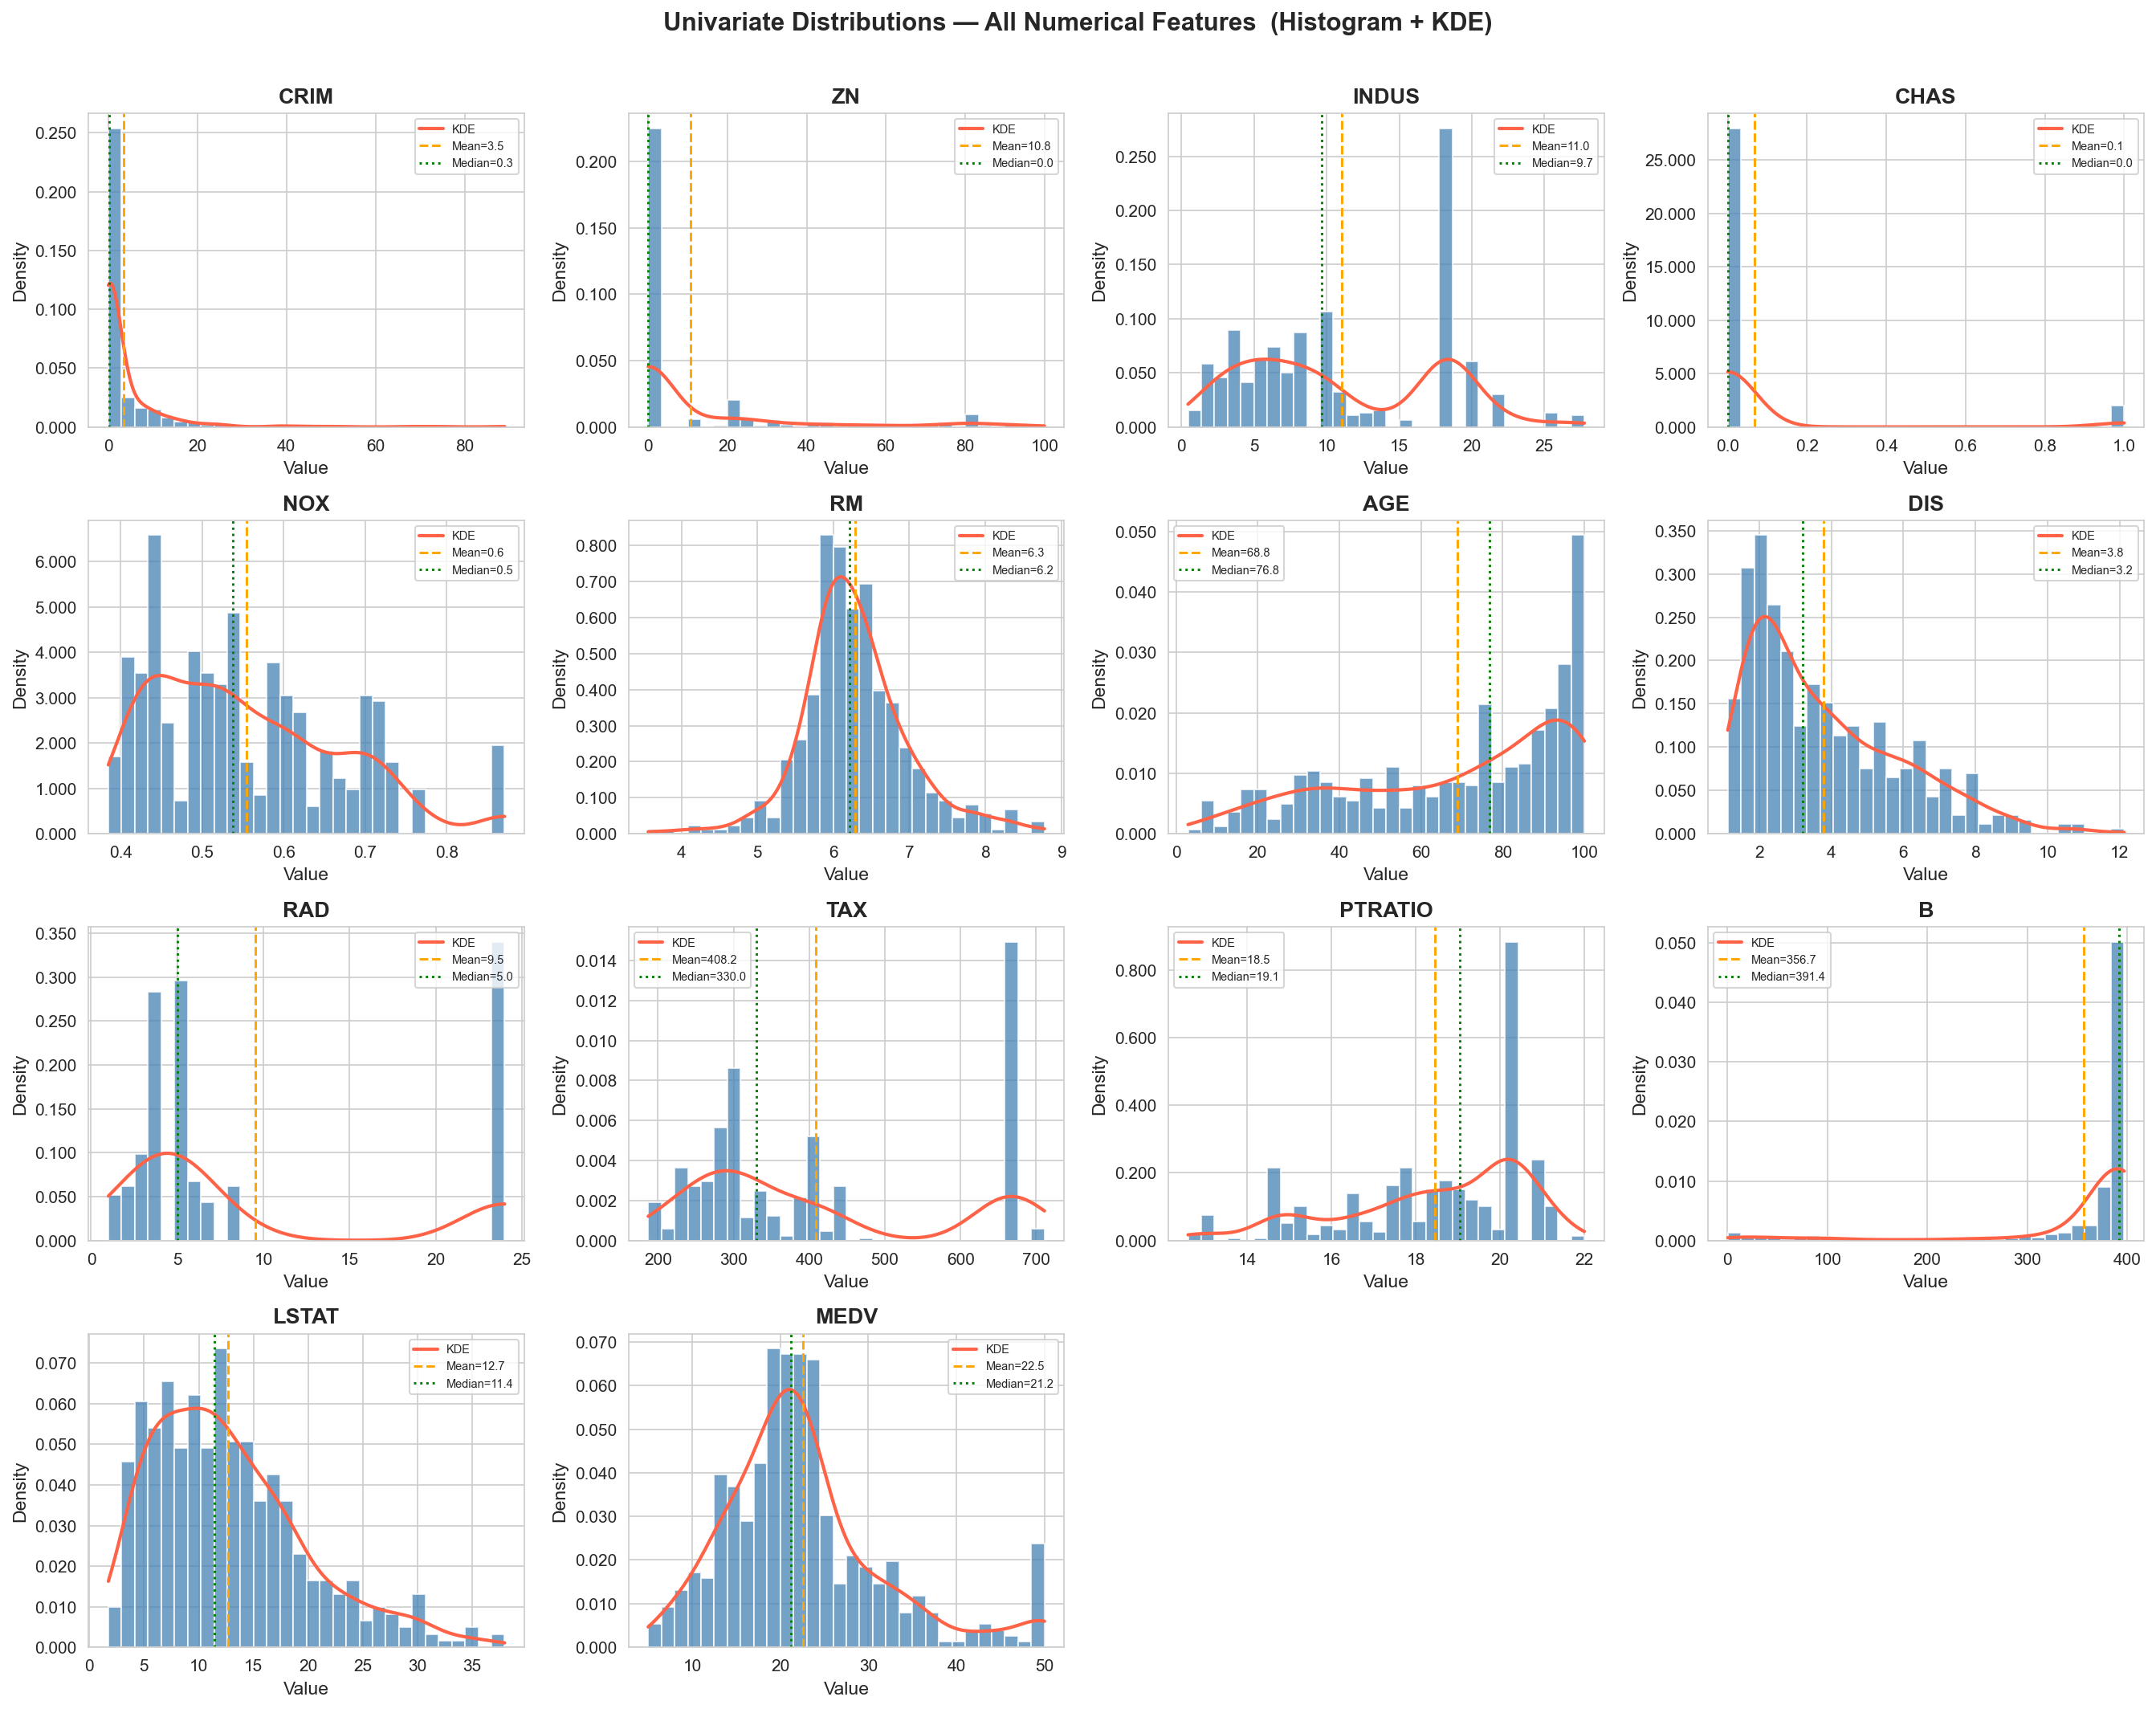

  → Saved: 03_histograms_kde_all_features.png

[5a] Skewness Summary:
Feature  Skewness            Shape
   CRIM     5.316   Right-skewed ▶
     ZN     2.325   Right-skewed ▶
  INDUS     0.334 Approx. Normal ≈
   CHAS     3.468   Right-skewed ▶
    NOX     0.729   Right-skewed ▶
     RM     0.404 Approx. Normal ≈
    AGE    -0.626    Left-skewed ◀
    DIS     1.012   Right-skewed ▶
    RAD     1.005   Right-skewed ▶
    TAX     0.670   Right-skewed ▶
PTRATIO    -0.802    Left-skewed ◀
      B    -2.890    Left-skewed ◀
  LSTAT     0.947   Right-skewed ▶
   MEDV     1.108   Right-skewed ▶

 SECTION 6 — BIVARIATE ANALYSIS  (Target: MEDV)


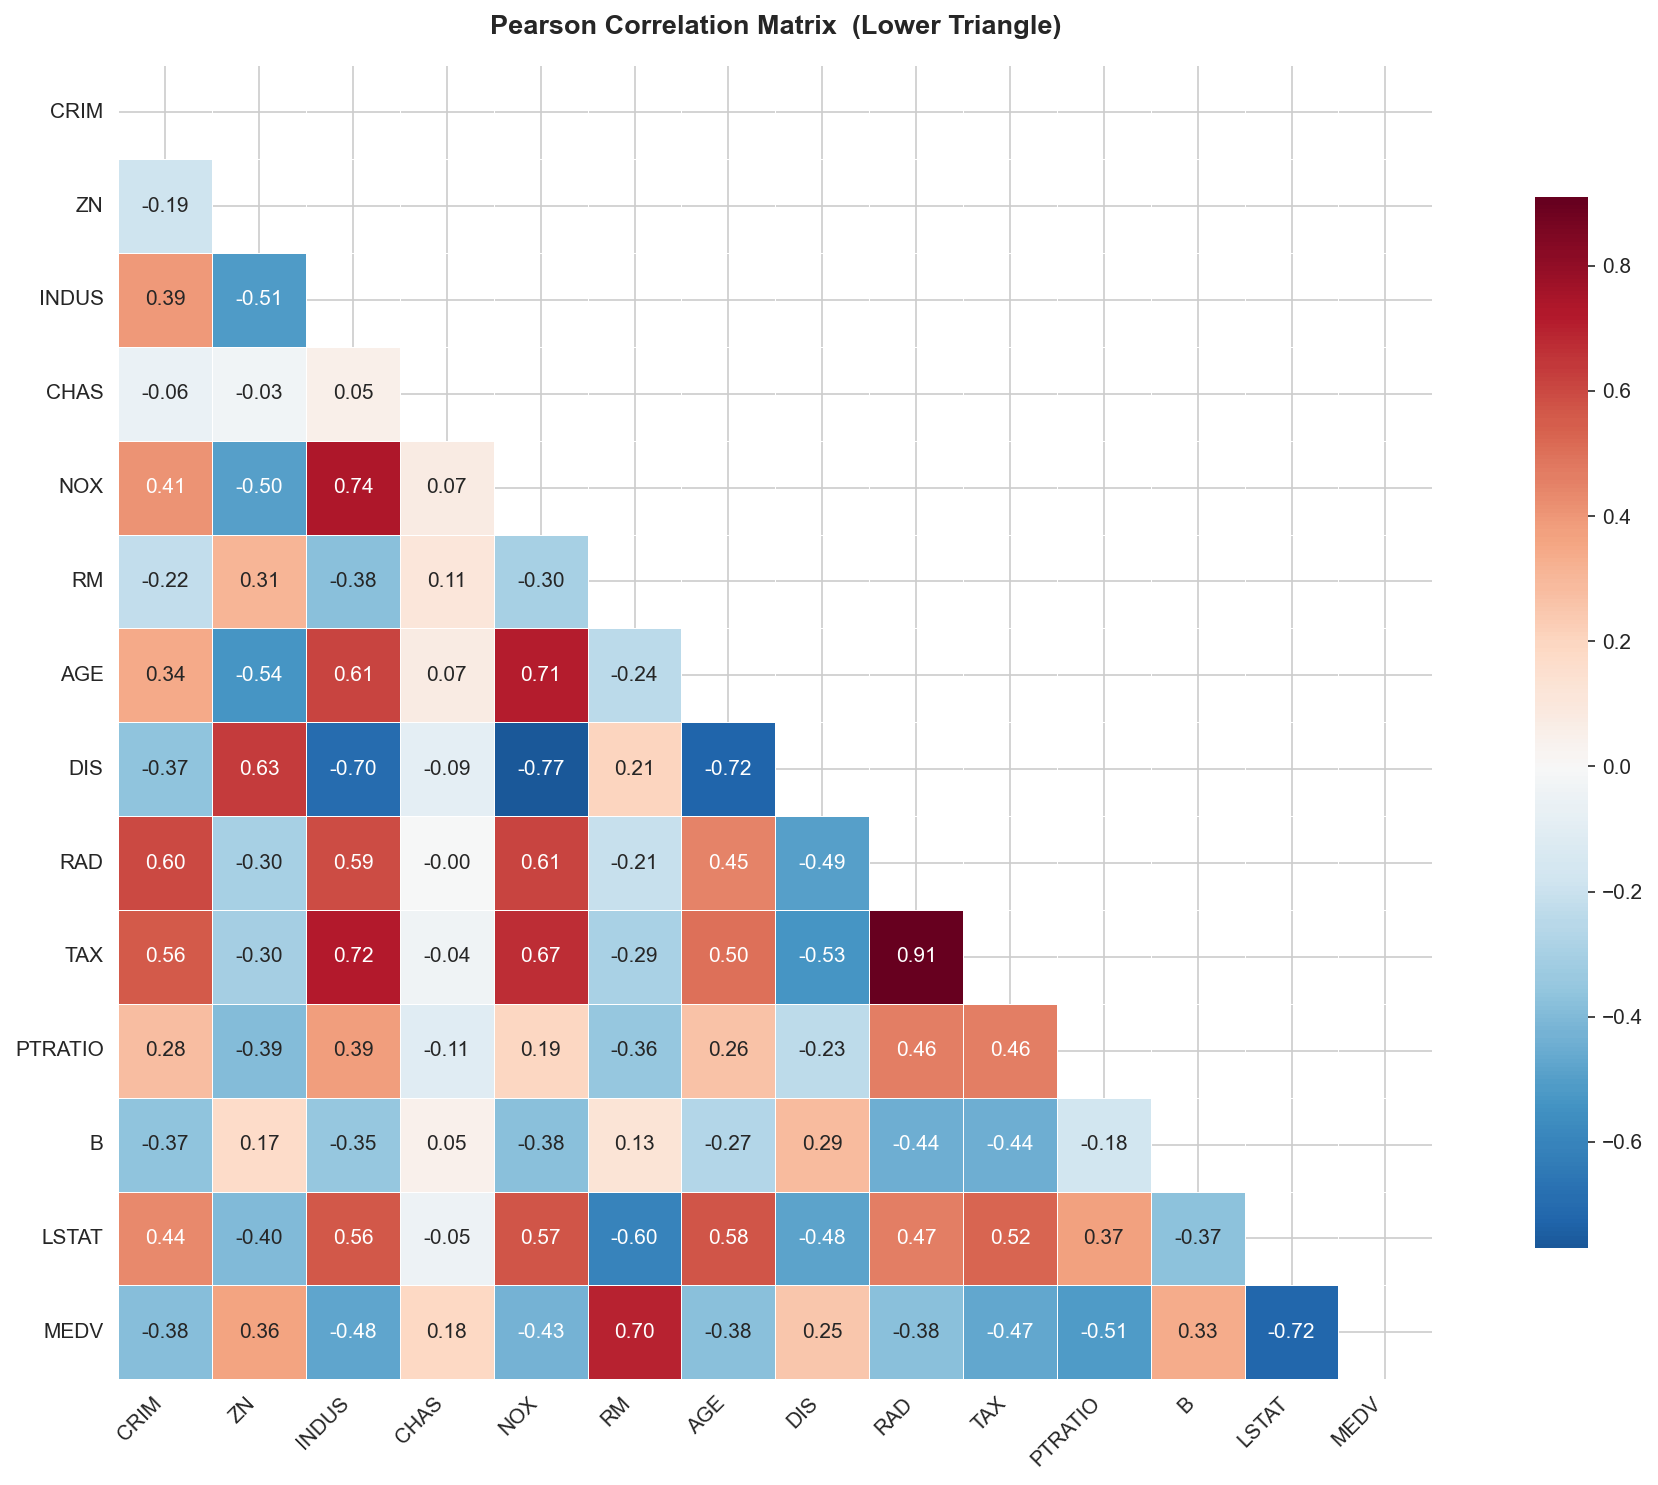

  → Saved: 04_correlation_matrix.png

[6a] Pearson Correlations with MEDV (sorted by |r|):

  LSTAT      r = -0.723  (↓ negative)
  RM         r = +0.695  (↑ positive)
  PTRATIO    r = -0.508  (↓ negative)
  INDUS      r = -0.476  (↓ negative)
  TAX        r = -0.469  (↓ negative)
  NOX        r = -0.427  (↓ negative)
  CRIM       r = -0.384  (↓ negative)
  RAD        r = -0.382  (↓ negative)
  AGE        r = -0.378  (↓ negative)
  ZN         r = +0.362  (↑ positive)
  B          r = +0.333  (↑ positive)
  DIS        r = +0.250  (↑ positive)
  CHAS       r = +0.184  (↑ positive)


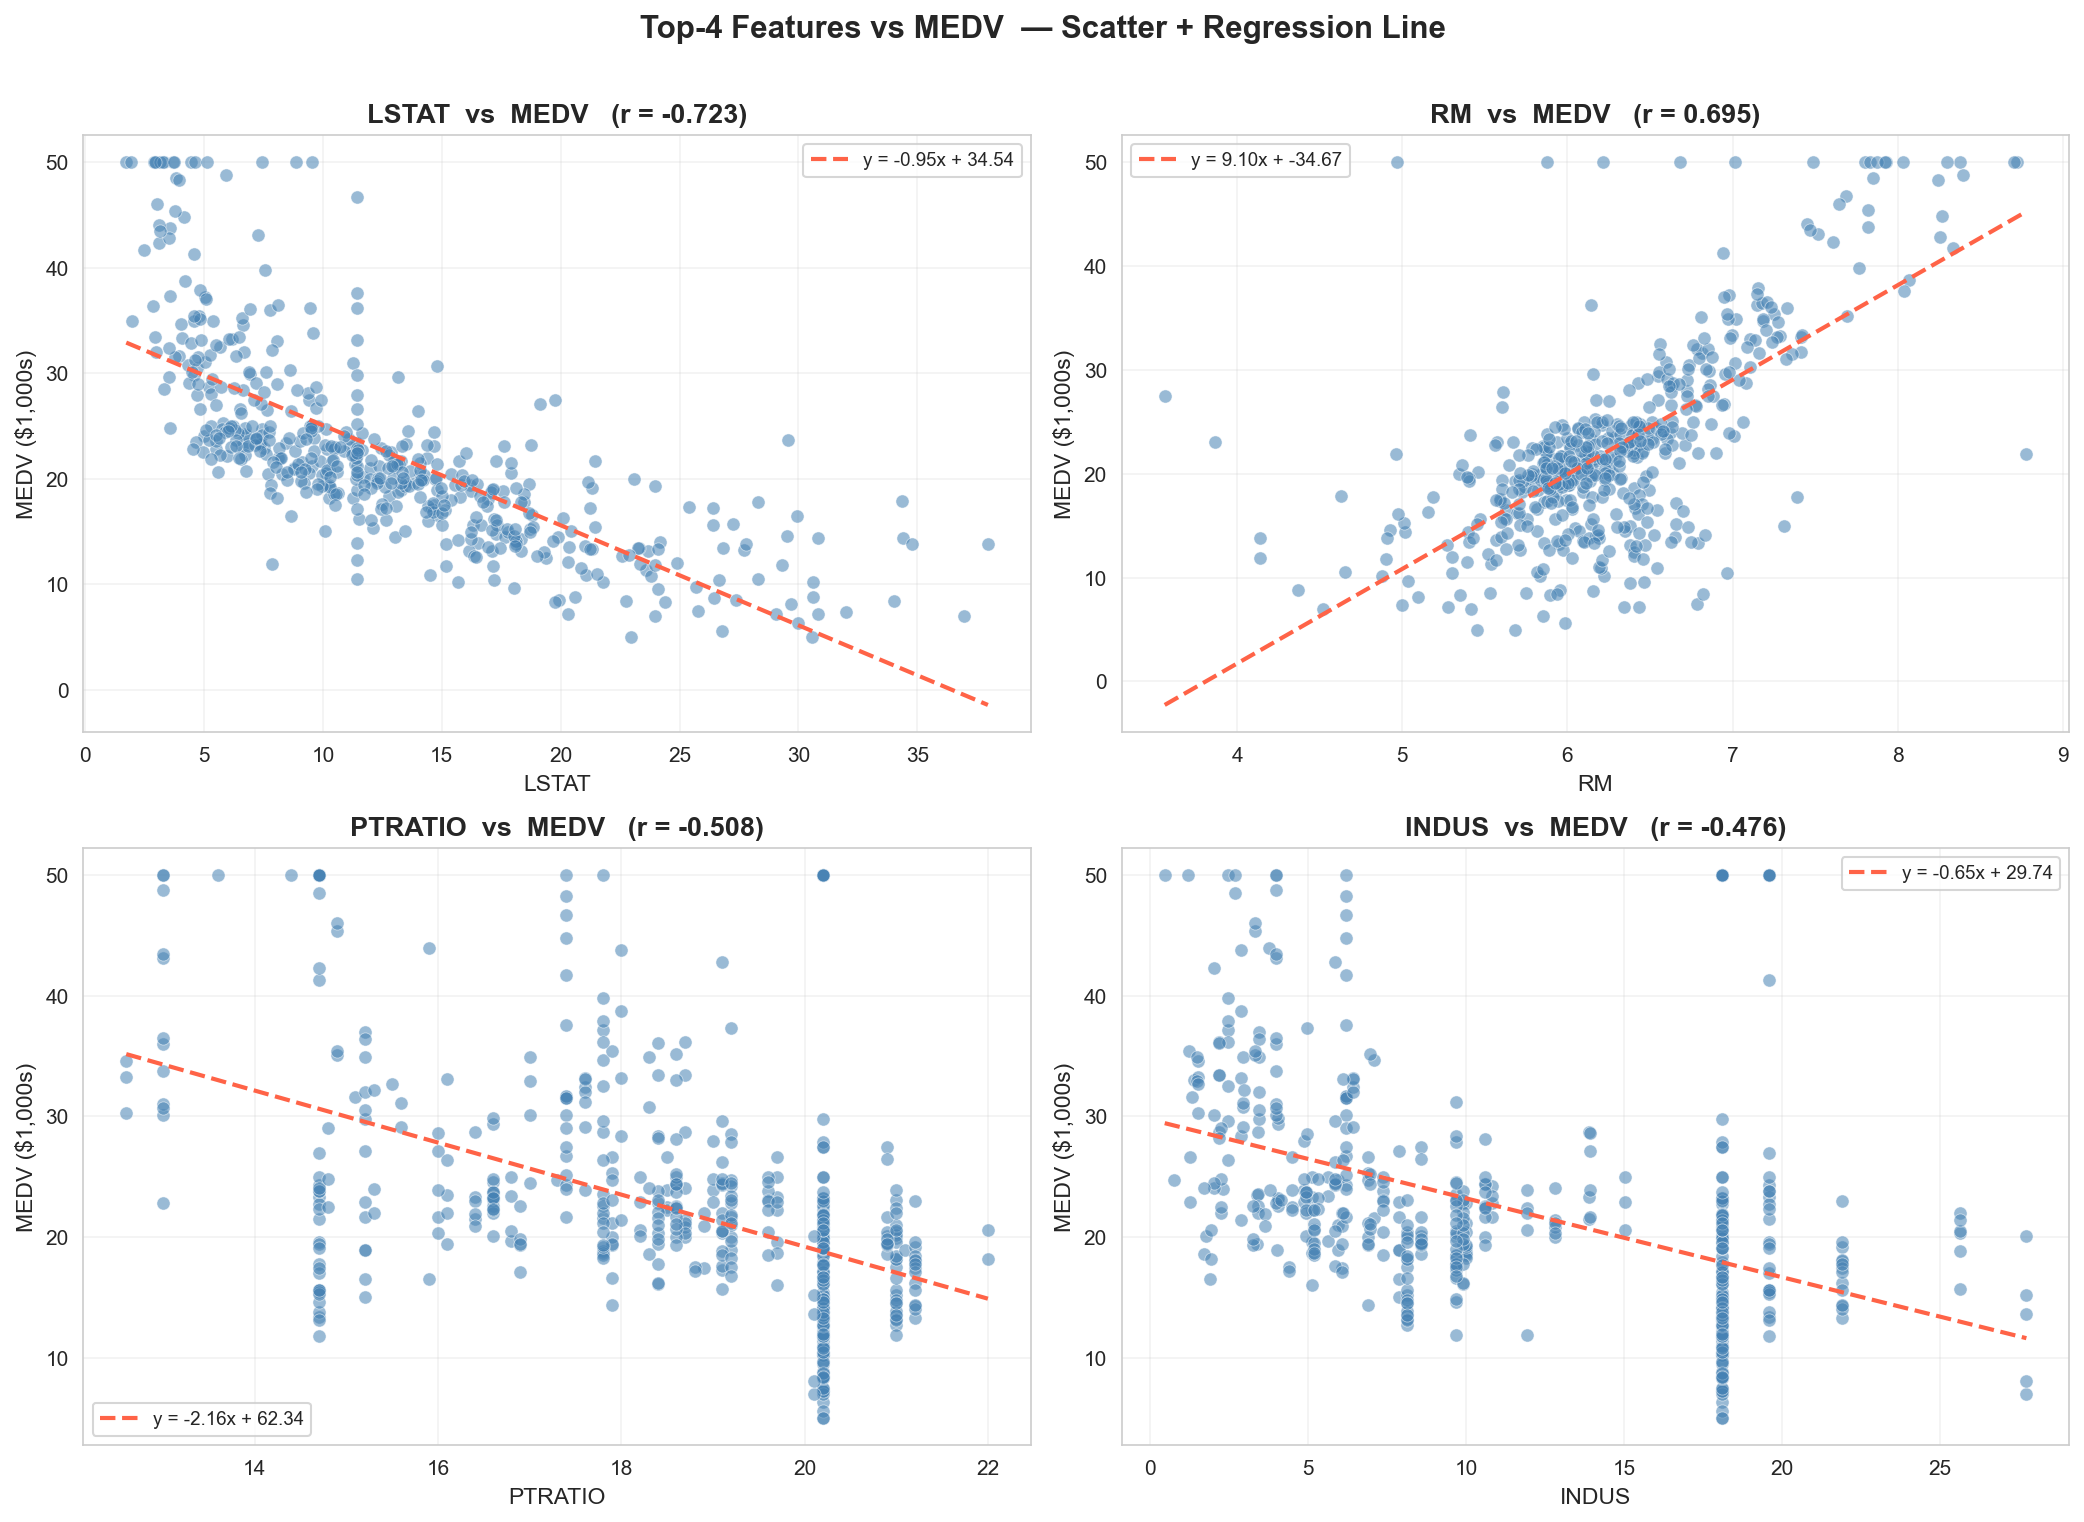


  → Saved: 05_scatter_top_features.png

 SECTION 7 — CATEGORICAL / GROUPED ANALYSIS


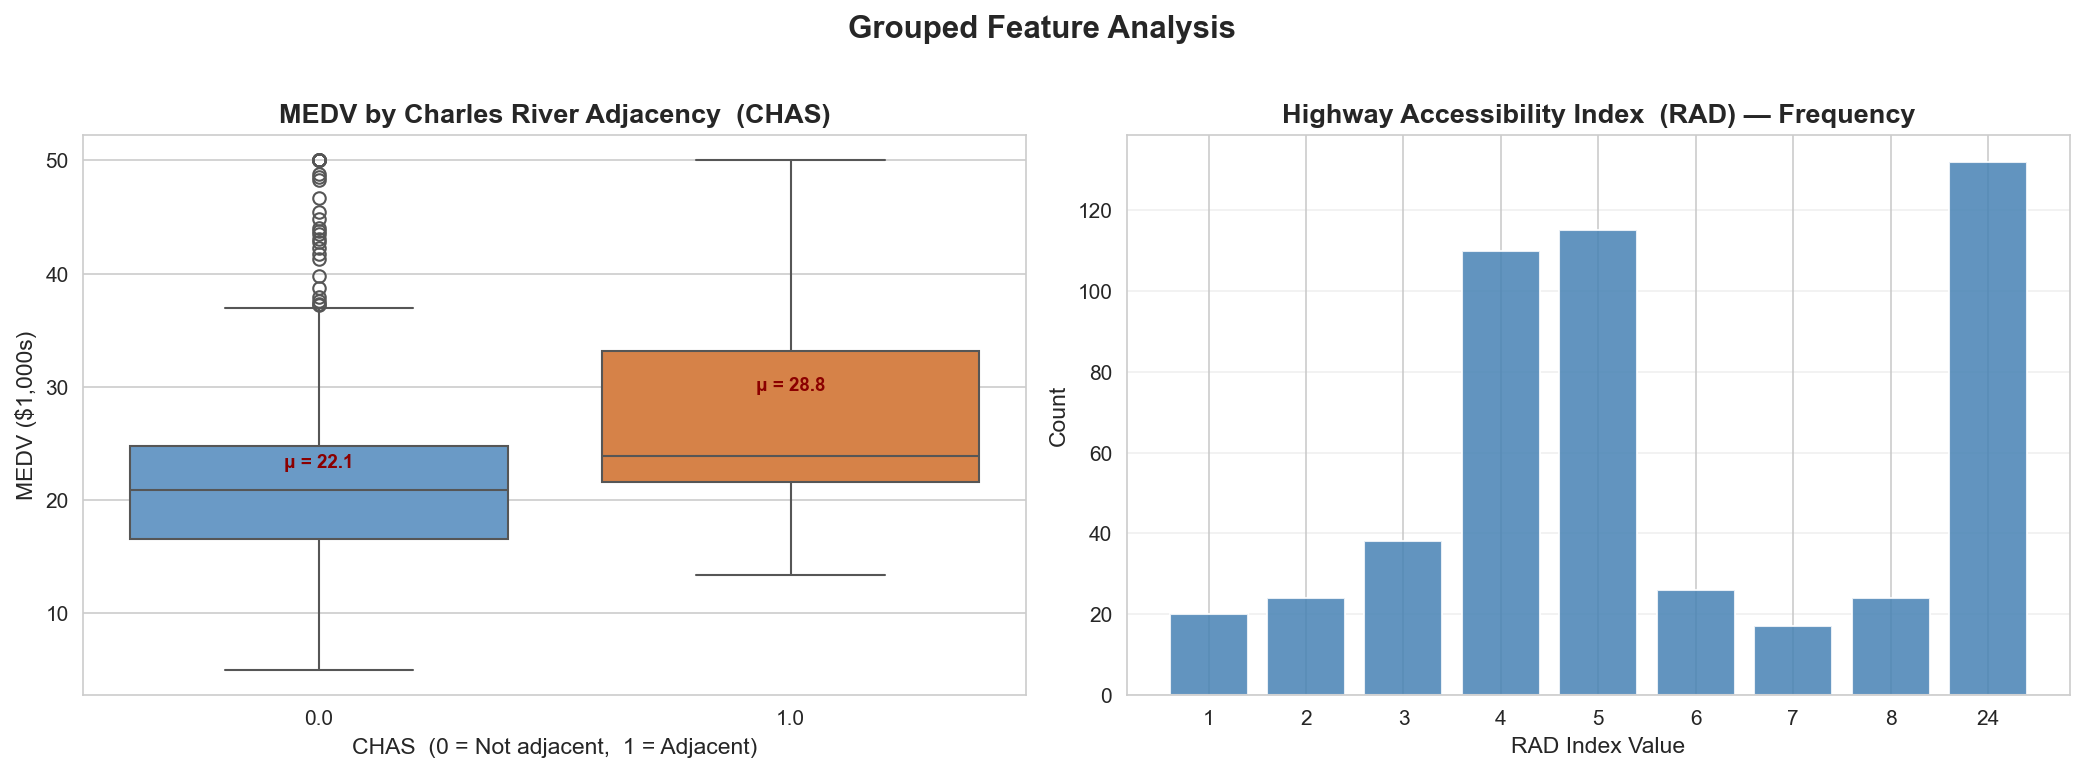

  → Saved: 06_categorical_analysis.png

[7a] MEDV Descriptive Statistics by CHAS:

      Count   Mean    Std   Min  Median   Max
CHAS                                         
0.0     472  22.08   8.83   5.0   20.85  50.0
1.0      34  28.83  11.77  13.4   23.85  50.0

 SECTION 8 — EDA SUMMARY & KEY INSIGHTS

┌─────────────────────────────────────────────────────────────┐
│                    DATASET OVERVIEW                         │
├─────────────────────────────────────────────────────────────┤
│  Rows            : 506    │  Columns : 14                 │
│  Missing values  : 0      │  Duplicates : 0               │
│  Target          : MEDV — Median Home Value ($1,000s)    │
│  Target Mean     : $22.53k  │  Std : $9.20k              │
│  Target Range    : $5.0k — $50.0k                         │
└─────────────────────────────────────────────────────────────┘

── KEY INSIGHTS ──────────────────────────────────────────────

  1. STRONGEST PREDICTORS OF HOME VALUE (MEDV)
     Positive c

In [3]:
"""
================================================================================
 Boston Housing Dataset — Exploratory Data Analysis (EDA)
================================================================================
 Author      : [Your Name]
 Date        : 2026
 Description : A professional EDA pipeline for the Boston Housing dataset.
               Covers data loading, cleaning, univariate/bivariate analysis,
               outlier detection, and a final insights summary.

 Dataset     : Boston Housing (HousingData.csv)
 Target      : MEDV — Median value of owner-occupied homes in $1,000s

 Features:
   CRIM    — Per capita crime rate by town
   ZN      — Proportion of residential land zoned for large lots
   INDUS   — Proportion of non-retail business acres per town
   CHAS    — Charles River dummy variable (1 if tract bounds river; 0 otherwise)
   NOX     — Nitric oxide concentration (parts per 10 million)
   RM      — Average number of rooms per dwelling
   AGE     — Proportion of owner-occupied units built before 1940
   DIS     — Weighted distances to Boston employment centres
   RAD     — Index of accessibility to radial highways
   TAX     — Full-value property-tax rate per $10,000
   PTRATIO — Pupil-teacher ratio by town
   B       — 1000(Bk - 0.63)^2 where Bk = proportion of Black residents
   LSTAT   — Percentage of lower-status population
   MEDV    — Median home value in $1,000s (TARGET)
================================================================================
"""

# ── Standard Library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# ── Third-Party Libraries ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Plot Defaults ─────────────────────────────────────────────────────────────
sns.set_style("whitegrid")
PALETTE   = "steelblue"
FIG_DPI   = 150
OUTPUT    = "outputs/"          # Change this to your desired output folder

plt.rcParams.update({
    "figure.figsize"  : (12, 8),
    "font.size"       : 10,
    "axes.titlesize"  : 13,
    "axes.titleweight": "bold",
    "axes.labelsize"  : 11,
    "figure.dpi"      : FIG_DPI,
})


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════

def load_data(filepath: str) -> pd.DataFrame:
    """
    Load the dataset from a CSV file and perform basic integrity checks.

    Parameters
    ----------
    filepath : str
        Path to the CSV file.

    Returns
    -------
    pd.DataFrame
        Loaded DataFrame.
    """
    df = pd.read_csv(filepath)

    print("=" * 65)
    print(" SECTION 1 — DATA LOADING")
    print("=" * 65)
    print(f"  ✔ File loaded       : {filepath}")
    print(f"  ✔ Shape             : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"  ✔ Memory usage      : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
    print(f"\nFirst 5 rows:\n{df.head()}\n")

    return df


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — DATA QUALITY ASSESSMENT
# ══════════════════════════════════════════════════════════════════════════════

def assess_data_quality(df: pd.DataFrame) -> None:
    """
    Print a structured report on data types, missing values, and duplicates.

    Parameters
    ----------
    df : pd.DataFrame
        Raw DataFrame to assess.
    """
    print("=" * 65)
    print(" SECTION 2 — DATA QUALITY ASSESSMENT")
    print("=" * 65)

    # ── Data types ────────────────────────────────────────────────────────────
    print("\n[2a] Column Data Types:")
    print(df.dtypes.to_string())

    # ── Missing values ────────────────────────────────────────────────────────
    missing_count = df.isnull().sum()
    missing_pct   = (missing_count / len(df) * 100).round(2)
    missing_df    = pd.DataFrame({
        "Missing Count": missing_count,
        "Missing %"    : missing_pct,
    })
    has_missing = missing_df[missing_df["Missing Count"] > 0]

    print(f"\n[2b] Missing Value Report ({len(has_missing)} column(s) affected):")
    if has_missing.empty:
        print("  No missing values detected.")
    else:
        print(has_missing.to_string())

    print(f"\n  Total missing cells : {df.isnull().sum().sum():,}")
    print(f"  Duplicate rows      : {df.duplicated().sum():,}\n")

    # ── Missing values heatmap ────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.heatmap(
        df.isnull(),
        cbar=False,
        cmap="viridis",
        yticklabels=False,
        ax=ax,
    )
    ax.set_title("Missing Values Heatmap  (yellow = missing)")
    ax.set_xlabel("Features")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT}01_missing_values_heatmap.png", bbox_inches="tight")
    plt.show()
    print("  → Saved: 01_missing_values_heatmap.png\n")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — DATA CLEANING
# ══════════════════════════════════════════════════════════════════════════════

def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Perform data cleaning:
      - Impute numerical missing values with the column median.
      - Impute categorical missing values with the column mode.
      - Drop exact duplicate rows.

    Median imputation is preferred over mean because it is robust to outliers,
    which are common in housing datasets (e.g., CRIM, B, LSTAT).

    Parameters
    ----------
    df : pd.DataFrame
        Raw DataFrame.

    Returns
    -------
    pd.DataFrame
        Cleaned DataFrame.
    """
    print("=" * 65)
    print(" SECTION 3 — DATA CLEANING")
    print("=" * 65)

    df_clean = df.copy()

    # ── Numerical imputation (median) ─────────────────────────────────────────
    num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    print(f"\n[3a] Numerical imputation (median strategy):")
    for col in num_cols:
        n_missing = df_clean[col].isnull().sum()
        if n_missing > 0:
            median = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(median)
            print(f"  {col:<10} → {n_missing} value(s) filled with median = {median:.3f}")

    # ── Categorical imputation (mode) ─────────────────────────────────────────
    cat_cols = df_clean.select_dtypes(include=["object", "category"]).columns.tolist()
    print(f"\n[3b] Categorical imputation (mode strategy):")
    if not cat_cols:
        print("  No categorical columns found — skipping.")
    else:
        for col in cat_cols:
            n_missing = df_clean[col].isnull().sum()
            if n_missing > 0:
                mode = df_clean[col].mode()
                fill_val = mode[0] if not mode.empty else "Unknown"
                df_clean[col] = df_clean[col].fillna(fill_val)
                print(f"  {col:<10} → {n_missing} value(s) filled with mode = '{fill_val}'")

    # ── Duplicate removal ─────────────────────────────────────────────────────
    before = len(df_clean)
    df_clean = df_clean.drop_duplicates()
    removed = before - len(df_clean)
    print(f"\n[3c] Duplicate removal:")
    print(f"  Removed {removed} duplicate row(s).")

    print(f"\n  ✔ Cleaned shape         : {df_clean.shape}")
    print(f"  ✔ Remaining missing cells: {df_clean.isnull().sum().sum()}\n")

    return df_clean


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — OUTLIER DETECTION
# ══════════════════════════════════════════════════════════════════════════════

def detect_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """
    Detect outliers using the IQR (interquartile range) method.
    Any value below Q1 - 1.5*IQR or above Q3 + 1.5*IQR is flagged.

    This does NOT remove outliers — housing data often contains legitimate
    extreme values (e.g., waterfront properties, high-crime areas).

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned DataFrame.

    Returns
    -------
    pd.DataFrame
        Summary table of outlier counts per feature.
    """
    print("=" * 65)
    print(" SECTION 4 — OUTLIER DETECTION  (IQR Method)")
    print("=" * 65)

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    records  = []

    for col in num_cols:
        q1, q3  = df[col].quantile([0.25, 0.75])
        iqr     = q3 - q1
        lower   = q1 - 1.5 * iqr
        upper   = q3 + 1.5 * iqr
        n_out   = ((df[col] < lower) | (df[col] > upper)).sum()
        records.append({
            "Feature"     : col,
            "Q1"          : round(q1,  3),
            "Q3"          : round(q3,  3),
            "IQR"         : round(iqr, 3),
            "Lower Fence" : round(lower, 3),
            "Upper Fence" : round(upper, 3),
            "Outliers"    : n_out,
            "Outlier %"   : f"{n_out / len(df) * 100:.1f}%",
        })

    outlier_df = pd.DataFrame(records).set_index("Feature")
    print(f"\n{outlier_df.to_string()}\n")

    # ── Boxplots ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 5, figsize=(20, 11))
    axes      = axes.ravel()

    for idx, col in enumerate(num_cols):
        sns.boxplot(y=df[col], ax=axes[idx], color="lightsteelblue",
                    flierprops=dict(marker="o", color="tomato", alpha=0.5, markersize=4))
        axes[idx].set_title(col)
        axes[idx].set_ylabel("")

    for idx in range(len(num_cols), len(axes)):
        fig.delaxes(axes[idx])

    plt.suptitle("Boxplots — Feature Outlier Visualisation (IQR Method)",
                 fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT}02_boxplots_all_features.png", bbox_inches="tight")
    plt.show()
    print("  → Saved: 02_boxplots_all_features.png\n")

    return outlier_df


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — UNIVARIATE ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

def univariate_analysis(df: pd.DataFrame) -> None:
    """
    Plot histograms with KDE overlays for every numerical feature.
    KDE (Kernel Density Estimation) helps visualise the underlying
    distribution shape beyond simple bin counts.

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned DataFrame.
    """
    print("=" * 65)
    print(" SECTION 5 — UNIVARIATE ANALYSIS  (Distributions)")
    print("=" * 65)

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    n_cols   = 4
    n_rows   = -(-len(num_cols) // n_cols)   # ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
    axes      = axes.ravel()

    for idx, col in enumerate(num_cols):
        ax = axes[idx]
        ax.hist(df[col], bins=30, color="steelblue", edgecolor="white",
                alpha=0.75, density=True)

        # Overlay KDE
        kde_x = np.linspace(df[col].min(), df[col].max(), 300)
        from scipy.stats import gaussian_kde
        kde   = gaussian_kde(df[col].dropna())
        ax.plot(kde_x, kde(kde_x), color="tomato", linewidth=2, label="KDE")

        # Annotate mean and median
        ax.axvline(df[col].mean(),   color="orange", linestyle="--",
                   linewidth=1.4, label=f"Mean={df[col].mean():.1f}")
        ax.axvline(df[col].median(), color="green",  linestyle=":",
                   linewidth=1.4, label=f"Median={df[col].median():.1f}")

        ax.set_title(col)
        ax.set_xlabel("Value")
        ax.set_ylabel("Density")
        ax.legend(fontsize=7)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

    for idx in range(len(num_cols), len(axes)):
        fig.delaxes(axes[idx])

    plt.suptitle("Univariate Distributions — All Numerical Features  (Histogram + KDE)",
                 fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT}03_histograms_kde_all_features.png", bbox_inches="tight")
    plt.show()
    print("  → Saved: 03_histograms_kde_all_features.png\n")

    # ── Skewness report ───────────────────────────────────────────────────────
    skew = df[num_cols].skew().round(3).reset_index()
    skew.columns = ["Feature", "Skewness"]
    skew["Shape"] = skew["Skewness"].apply(
        lambda s: "Right-skewed ▶" if s > 0.5
        else ("Left-skewed ◀" if s < -0.5 else "Approx. Normal ≈")
    )
    print("[5a] Skewness Summary:")
    print(skew.to_string(index=False))
    print()


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — BIVARIATE ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

def bivariate_analysis(df: pd.DataFrame, target: str = "MEDV") -> None:
    """
    Perform bivariate analysis:
      - Pearson correlation heatmap for all feature pairs.
      - Scatter plots of the top-4 features most correlated with the target.

    Parameters
    ----------
    df     : pd.DataFrame
        Cleaned DataFrame.
    target : str
        Name of the target variable (default: "MEDV").
    """
    print("=" * 65)
    print(f" SECTION 6 — BIVARIATE ANALYSIS  (Target: {target})")
    print("=" * 65)

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    corr     = df[num_cols].corr()

    # ── Correlation heatmap ───────────────────────────────────────────────────
    mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle

    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        linewidths=0.4,
        square=True,
        cbar_kws={"shrink": 0.8},
        ax=ax,
    )
    ax.set_title("Pearson Correlation Matrix  (Lower Triangle)", pad=15)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT}04_correlation_matrix.png", bbox_inches="tight")
    plt.show()
    print("  → Saved: 04_correlation_matrix.png\n")

    # ── Correlation with target ───────────────────────────────────────────────
    target_corr = (
        corr[target]
        .drop(target)
        .sort_values(key=abs, ascending=False)
    )
    print(f"[6a] Pearson Correlations with {target} (sorted by |r|):\n")
    for feat, r in target_corr.items():
        direction = "↑ positive" if r > 0 else "↓ negative"
        print(f"  {feat:<10} r = {r:+.3f}  ({direction})")

    # ── Top 4 scatter plots ───────────────────────────────────────────────────
    top_features = target_corr.head(4).index.tolist()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes      = axes.ravel()

    for idx, feat in enumerate(top_features):
        ax = axes[idx]
        ax.scatter(df[feat], df[target], alpha=0.55, color="steelblue",
                   edgecolors="white", linewidth=0.4, s=40)

        # Regression trend line
        m, b = np.polyfit(df[feat], df[target], 1)
        x_range = np.linspace(df[feat].min(), df[feat].max(), 200)
        ax.plot(x_range, m * x_range + b, color="tomato",
                linewidth=2, linestyle="--", label=f"y = {m:.2f}x + {b:.2f}")

        r = df[feat].corr(df[target])
        ax.set_xlabel(feat)
        ax.set_ylabel(f"{target} ($1,000s)")
        ax.set_title(f"{feat}  vs  {target}   (r = {r:.3f})")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.25)

    plt.suptitle(f"Top-4 Features vs {target}  — Scatter + Regression Line",
                 fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT}05_scatter_top_features.png", bbox_inches="tight")
    plt.show()
    print("\n  → Saved: 05_scatter_top_features.png\n")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7 — CATEGORICAL / GROUPED ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

def categorical_analysis(df: pd.DataFrame, target: str = "MEDV") -> None:
    """
    Analyse the target variable across categorical-style features:
      - CHAS : binary — Charles River adjacency (0 = No, 1 = Yes)
      - RAD  : index — Radial highway accessibility

    Parameters
    ----------
    df     : pd.DataFrame
        Cleaned DataFrame.
    target : str
        Name of the target variable.
    """
    print("=" * 65)
    print(" SECTION 7 — CATEGORICAL / GROUPED ANALYSIS")
    print("=" * 65)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── CHAS: MEDV boxplot ────────────────────────────────────────────────────
    sns.boxplot(
        x="CHAS", y=target, data=df,
        palette=["#5b9bd5", "#ed7d31"],
        ax=axes[0],
    )
    axes[0].set_title(f"{target} by Charles River Adjacency  (CHAS)")
    axes[0].set_xlabel("CHAS  (0 = Not adjacent,  1 = Adjacent)")
    axes[0].set_ylabel(f"{target} ($1,000s)")

    for i, (label, group) in enumerate(df.groupby("CHAS")[target]):
        axes[0].text(i, group.mean() + 0.8,
                     f"μ = {group.mean():.1f}",
                     ha="center", color="darkred", fontweight="bold", fontsize=9)

    # ── RAD: frequency bar chart ──────────────────────────────────────────────
    rad_counts = df["RAD"].value_counts().sort_index()
    axes[1].bar(rad_counts.index.astype(str), rad_counts.values,
                color="steelblue", edgecolor="white", alpha=0.85)
    axes[1].set_title("Highway Accessibility Index  (RAD) — Frequency")
    axes[1].set_xlabel("RAD Index Value")
    axes[1].set_ylabel("Count")
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.suptitle("Grouped Feature Analysis", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT}06_categorical_analysis.png", bbox_inches="tight")
    plt.show()
    print("  → Saved: 06_categorical_analysis.png\n")

    # ── Descriptive stats by CHAS ─────────────────────────────────────────────
    print(f"[7a] {target} Descriptive Statistics by CHAS:\n")
    chas_stats = df.groupby("CHAS")[target].agg(
        Count="count", Mean="mean", Std="std", Min="min", Median="median", Max="max"
    ).round(2)
    print(chas_stats.to_string())
    print()


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8 — EDA SUMMARY & KEY INSIGHTS
# ══════════════════════════════════════════════════════════════════════════════

def eda_summary(df: pd.DataFrame, outlier_df: pd.DataFrame, target: str = "MEDV") -> None:
    """
    Print a concise, structured summary of all EDA findings.
    This section is designed to communicate insights clearly to both
    technical and non-technical stakeholders.

    Parameters
    ----------
    df         : pd.DataFrame
        Cleaned DataFrame.
    outlier_df : pd.DataFrame
        Outlier summary from detect_outliers().
    target     : str
        Name of the target variable.
    """
    num_cols   = df.select_dtypes(include=[np.number]).columns.tolist()
    corr       = df[num_cols].corr()
    target_corr = corr[target].drop(target).sort_values(key=abs, ascending=False)

    top_pos    = target_corr[target_corr > 0].head(3)
    top_neg    = target_corr[target_corr < 0].head(3)
    most_out   = outlier_df["Outliers"].idxmax()

    print("=" * 65)
    print(" SECTION 8 — EDA SUMMARY & KEY INSIGHTS")
    print("=" * 65)

    print(f"""
┌─────────────────────────────────────────────────────────────┐
│                    DATASET OVERVIEW                         │
├─────────────────────────────────────────────────────────────┤
│  Rows            : {df.shape[0]:<5}  │  Columns : {df.shape[1]:<5}              │
│  Missing values  : {df.isnull().sum().sum():<5}  │  Duplicates : {df.duplicated().sum():<5}           │
│  Target          : {target} — Median Home Value ($1,000s)    │
│  Target Mean     : ${df[target].mean():.2f}k  │  Std : ${df[target].std():.2f}k              │
│  Target Range    : ${df[target].min():.1f}k — ${df[target].max():.1f}k                         │
└─────────────────────────────────────────────────────────────┘
""")

    print("── KEY INSIGHTS ──────────────────────────────────────────────\n")

    print("  1. STRONGEST PREDICTORS OF HOME VALUE (MEDV)")
    print("     Positive correlations — higher value → higher MEDV:")
    for feat, r in top_pos.items():
        print(f"       {feat:<10} r = {r:+.3f}")
    print("     Negative correlations — higher value → lower MEDV:")
    for feat, r in top_neg.items():
        print(f"       {feat:<10} r = {r:+.3f}")

    print(f"""
  2. OUTLIERS
     Most outlier-prone feature: {most_out}
       ({outlier_df.loc[most_out, 'Outliers']} outliers — {outlier_df.loc[most_out, 'Outlier %']})
     Note: Outliers were retained. Housing data extreme values can be
     legitimate (e.g., luxury properties, high-crime zones) and should
     be evaluated in the context of modelling rather than discarded.

  3. DISTRIBUTION SHAPES
     Several features exhibit strong right skew (CRIM, ZN, B),
     suggesting log-transformation may improve model performance.
     RM (rooms per dwelling) is the most normally distributed feature
     and shows a strong positive linear relationship with MEDV.

  4. CHARLES RIVER ADJACENCY (CHAS)
     Homes adjacent to the Charles River command a meaningful premium.
     Mean MEDV: ${df[df['CHAS']==1][target].mean():.1f}k (adjacent) vs
               ${df[df['CHAS']==0][target].mean():.1f}k (not adjacent).

  5. MULTICOLLINEARITY FLAGS
     TAX and RAD are highly correlated ({corr.loc['TAX','RAD']:.2f}),
     which may cause instability in linear regression models.
     Feature selection or regularisation (Ridge/Lasso) is recommended.

── RECOMMENDED NEXT STEPS ────────────────────────────────────

  • Feature Engineering : Log-transform skewed features (CRIM, ZN, B).
  • Modelling           : Baseline with Linear Regression → compare
                         Random Forest / XGBoost for non-linear patterns.
  • Validation          : Use k-fold cross-validation (k=5 or 10).
  • Evaluation Metrics  : RMSE, MAE, and R² on a held-out test set.

═══════════════════════════════════════════════════════════════
  EDA complete. All plots saved to: {OUTPUT}
═══════════════════════════════════════════════════════════════
""")


# ══════════════════════════════════════════════════════════════════════════════
# MAIN — PIPELINE ENTRY POINT
# ══════════════════════════════════════════════════════════════════════════════

def main() -> None:
    """
    Execute the full EDA pipeline in sequence:
      1. Load data
      2. Assess data quality
      3. Clean data
      4. Detect outliers
      5. Univariate analysis
      6. Bivariate analysis
      7. Categorical / grouped analysis
      8. EDA summary & key insights
    """
    import os
    os.makedirs(OUTPUT, exist_ok=True)

    # ── Run pipeline ──────────────────────────────────────────────────────────
    df             = load_data("HousingData.csv")
    assess_data_quality(df)
    df_clean       = clean_data(df)
    outlier_df     = detect_outliers(df_clean)
    univariate_analysis(df_clean)
    bivariate_analysis(df_clean, target="MEDV")
    categorical_analysis(df_clean, target="MEDV")
    eda_summary(df_clean, outlier_df, target="MEDV")


if __name__ == "__main__":
    main()